In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import mesa

from model import SocialGPModel
from rewards import (
    sample_children_with_corr,
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    build_corr_matrix_option2,
    build_corr_matrix_option3,
    _min_max,
)
from tqdm import tqdm

In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

## Plot correlations

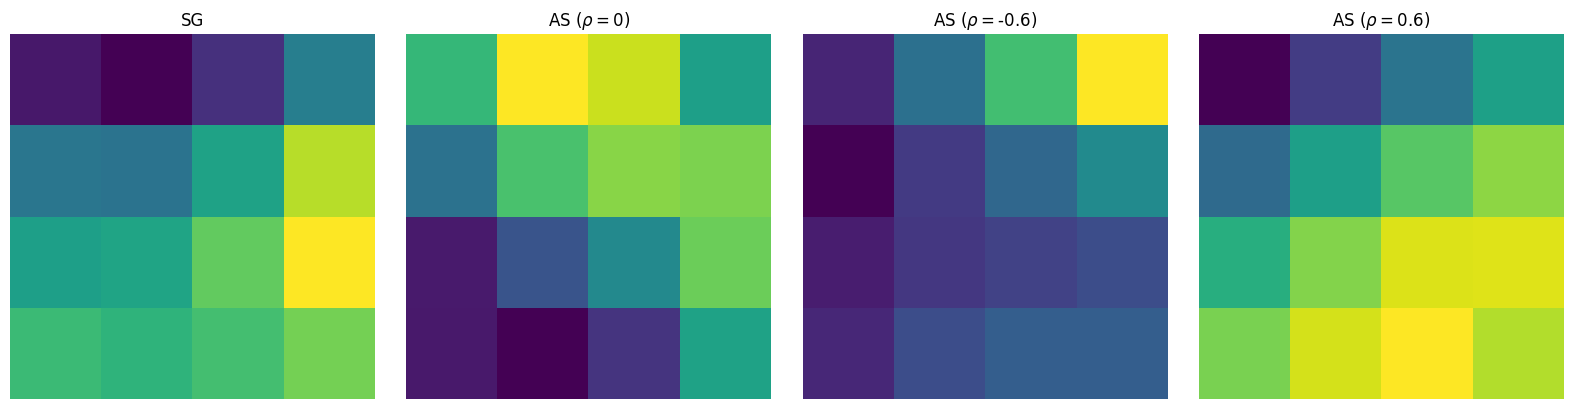

In [82]:
corr_matrix = build_corr_matrix_option1()  # parent + 3 children
n_children = corr_matrix.shape[0] - 1

seed = 0
a_rng = np.random.default_rng(seed)

grid_size = 4
parent, child_maps = make_parent_and_children_cholesky2(
    rng=a_rng,
    grid_size=grid_size,
    n_children=n_children + 1,
    length_scale=2.0,
    corr_matrix=corr_matrix,
)

# keep reward scale consistent with other sims
child_maps = [_min_max(c) - 0.5 for c in child_maps]

fig, axes = plt.subplots(1, len(child_maps) + 1, figsize=(4 * (len(child_maps) + 1), 4))

# parent
axes[0].imshow(_min_max(parent) - 0.5, origin='lower')
axes[0].set_title("SG")
axes[0].axis('off')

# children
for _corr, c, ax in zip([0, -0.6, 0.6], child_maps, axes[1:]):
    ax.imshow(c, origin='lower')
    ax.set_title(fr"AS ($\rho=${_corr})")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Run the model

In [88]:
m = SocialGPModel(
    n=n_children + 1,
    model_type="SG-ICM",
    child_maps=[parent] + child_maps,
    network_type="directed_one_to_four",
    rho=np.array([1.0, 0.0, -0.6, 0.6]),
    tau_sampling=True, # tau=0.03,
)

for _ in range(15):
    m.step()

results = m.datacollector.get_agent_vars_dataframe()

results.head(20)

choice    reward  cumulative_reward model_type      tau
Step AgentID                                                         
1    1        (2, 3)  0.330658           0.330658     SG-ICM  0.01856
     2        (1, 1) -0.242783          -0.242783         AS  0.01856
     3        (1, 0) -0.149983          -0.149983         AS  0.01856
     4        (3, 2)  0.205299           0.205299         AS  0.01856
2    1        (0, 0)  0.305029           0.135687     SG-ICM  0.01856
     2        (3, 3)  0.091170          -0.651613         AS  0.01856
     3        (3, 3) -0.432832          -1.082814         AS  0.01856
     4        (0, 0) -0.381075          -0.675776         AS  0.01856
3    1        (3, 0) -0.497139          -0.861452     SG-ICM  0.01856
     2        (0, 3)  0.070682          -1.080931         AS  0.01856
     3        (0, 3)  0.367871          -1.214944         AS  0.01856
     4        (0, 3) -0.211620          -1.387395         AS  0.01856
4    1        (3, 3)  0.080321          -1.281131     SG-ICM  0.01856
     2        (3, 0)  0.151874          -1.429057         AS  0.01856
     3        (0, 3)  0.362537          -1.352407         AS  0.01856
     4        (3, 0) -0.392394          -2.279790         AS  0.01856
5    1        (0, 1)  0.436692          -1.344439     SG-ICM  0.01856
     2        (0, 0) -0.429244          -2.358300         AS  0.01856
     3        (0, 2)  0.177246          -1.675161         AS  0.01856
     4        (3, 3)  0.503508          -2.276281         AS  0.01856

In [14]:
R = build_corr_matrix_option1()

param_grid = {
    "n": 4,
    "model_type": "SG-ICM",
    "observation_noise_private": 0.0001,
    "observation_noise_social":  0.0001,
    "length_scale_private": 1.11,
    "beta_private": 0.33,
    "beta_social": 0.33,
    "tau_sampling": True,
    "seed": list(range(100)),
    "network_type": "directed_one_to_four",
    "rho": [
        np.array([1.0, 0.0, -0.6, 0.6]),
        np.array([1.0, 0.0, 0.0, 0.0]), 
        np.array([1.0, 0.0, 0.6, -0.6])
           ],
    "corr_matrix": [R]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=param_grid,
    iterations=1,
    max_steps=15,
    number_processes=None,
    data_collection_period=1,
    display_progress=True,
)

batch_results = pd.DataFrame(batch_results)

  0%|          | 0/300 [00:00<?, ?it/s]

In [10]:
batch_results.head()

,RunId,iteration,Step,n,model_type,observation_noise_private,observation_noise_social,length_scale_private,beta_private,beta_social,tau_sampling,seed,network_type,rho,corr_matrix,avg_cumulative_reward,avg_reward,AgentID,choice,reward,cumulative_reward,tau
0,3,0,0,4,SG-ICM,0.0001,0.0001,1.11,0.33,0.33,True,1,directed_one_to_four,"[1.0, 0.0, 0.0, 0.0]","[[1.0, 0.0, -0.6, 0.6], [0.0, 1.0, 0.0, 0.0], ...",0.559337,0.559337,NaN,NaN,NaN,NaN,NaN
1,3,0,1,4,SG-ICM,0.0001,0.0001,1.11,0.33,0.33,True,1,directed_one_to_four,"[1.0, 0.0, 0.0, 0.0]","[[1.0, 0.0, -0.6, 0.6], [0.0, 1.0, 0.0, 0.0], ...",1.127107,0.563553,1.0,"(6, 1)",0.859627,0.859627,0.014396
2,3,0,1,4,AS,0.0001,0.0001,1.11,0.33,0.33,True,1,directed_one_to_four,"[1.0, 0.0, 0.0, 0.0]","[[1.0, 0.0, -0.6, 0.6], [0.0, 1.0, 0.0, 0.0], ...",1.127107,0.563553,2.0,"(6, 6)",0.474450,0.474450,0.014396
3,3,0,1,4,AS,0.0001,0.0001,1.11,0.33,0.33,True,1,directed_one_to_four,"[1.0, 0.0, 0.0, 0.0]","[[1.0, 0.0, -0.6, 0.6], [0.0, 1.0, 0.0, 0.0], ...",1.127107,0.563553,3.0,"(9, 9)",0.361007,0.361007,0.014396
4,3,0,1,4,AS,0.0001,0.0001,1.11,0.33,0.33,True,1,directed_one_to_four,"[1.0, 0.0, 0.0, 0.0]","[[1.0, 0.0, -0.6, 0.6], [0.0, 1.0, 0.0, 0.0], ...",1.127107,0.563553,4.0,"(3, 9)",0.542263,0.542263,0.014396


In [15]:
batch_results['rho_str'] = [str(l) for l in batch_results['rho'].to_list()]

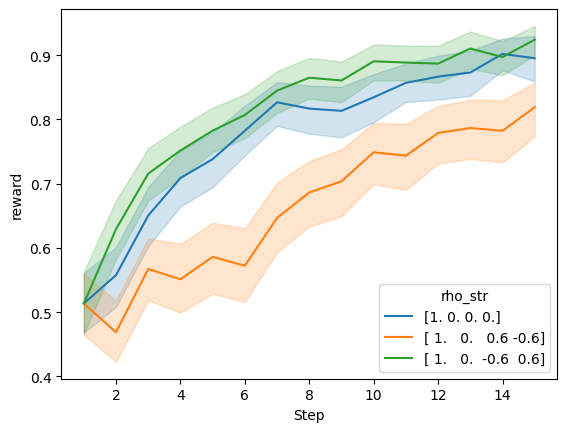

In [16]:
sns.lineplot(batch_results[batch_results.model_type == "SG-ICM"],
             x="Step",
             y="reward",
             hue="rho_str",
             # hue_order=["[ 1.   0.  -0.6  0.6]", "[1. 0. 0. 0.]", "[ 1.   0.  0.6 -0.6]"]
             )
plt.show()

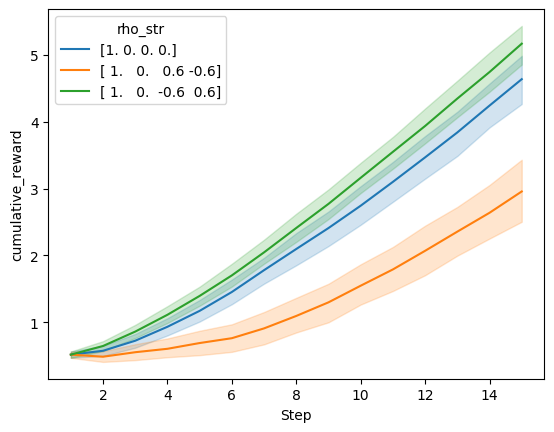

In [17]:
sns.lineplot(batch_results[batch_results.model_type == "SG-ICM"],
             x="Step",
             y="cumulative_reward",
             hue="rho_str",
             # hue_order=["[ 1.   0.  -0.6  0.6]", "[1. 0. 0. 0.]", "[ 1.   0.5  0.6 -0.6]"]
             )
plt.show()